<h1 align='center' style='color:#4A90D9;'>🔢 Handwritten Digit Recognizer</h1>
<h3 align='center'>Minor Project | AI/ML | Artificial Neural Network (ANN)</h3>

<hr>

| Detail | Info |
|---|---|
| **Project Type** | Minor Project |
| **Domain** | Deep Learning / Computer Vision |
| **Dataset** | MNIST (Modified National Institute of Standards and Technology) |
| **Algorithm** | Artificial Neural Network (ANN) |
| **Framework** | TensorFlow 2.x / Keras |
| **Language** | Python 3.x |
| **Platform** | Google Colab |
| **Expected Accuracy** | ~97–98% |

<hr>

## 📌 1. Project Overview

### 1.1 Problem Statement
Handwriting recognition is one of the foundational problems in computer vision and pattern recognition. The goal of this project is to build a machine learning model that can **automatically identify handwritten digits (0–9)** from grayscale images with high accuracy.

### 1.2 Objective
- Train an **Artificial Neural Network (ANN)** on the MNIST dataset
- Achieve a test accuracy of at least **97%**
- Visualize the training process, model performance, and predictions

### 1.3 Real-World Applications
- 🏦 **Banking** — Reading handwritten cheque amounts
- 📮 **Postal Services** — Sorting letters by zip/pin codes
- 📝 **Education** — Automated answer sheet evaluation
- 🏥 **Healthcare** — Digitizing handwritten prescriptions
- 📋 **Forms Processing** — Government & insurance form reading

### 1.4 Workflow
```
Load Dataset → Preprocess → Build ANN → Train → Evaluate → Visualize → Save Model
```

## 📦 2. About the Dataset — MNIST

The **MNIST (Modified National Institute of Standards and Technology)** database is one of the most famous benchmark datasets in machine learning.

| Property | Details |
|---|---|
| **Total Samples** | 70,000 images |
| **Training Set** | 60,000 images |
| **Test Set** | 10,000 images |
| **Image Size** | 28 × 28 pixels |
| **Color** | Grayscale (single channel) |
| **Classes** | 10 (digits 0 through 9) |
| **Pixel Range** | 0 (black) to 255 (white) |
| **Source** | Built into `tensorflow.keras.datasets` |

> 💡 **No manual download needed!** MNIST is pre-bundled with Keras and downloads automatically on first run.

## ⚙️ 3. Install & Import Libraries

In [1]:
# Install required libraries (already available in Colab)
# Uncomment only if running locally
# !pip install tensorflow numpy matplotlib seaborn scikit-learn

In [2]:
# ── Core Libraries ──────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── TensorFlow / Keras ──────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ── Scikit-Learn Metrics ────────────────────────────────────
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

# ── Reproducibility ─────────────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)

print('✅ All libraries imported successfully!')
print(f'   TensorFlow version : {tf.__version__}')
print(f'   NumPy version      : {np.__version__}')
print(f'   GPU Available      : {len(tf.config.list_physical_devices("GPU")) > 0}')

✅ All libraries imported successfully!
   TensorFlow version : 2.20.0
   NumPy version      : 2.0.2
   GPU Available      : False


## 📥 4. Load & Explore the Dataset

In [3]:
# Load MNIST dataset (auto-downloads ~11MB on first run)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print('=' * 45)
print('         MNIST DATASET SUMMARY')
print('=' * 45)
print(f'  Training images  : {X_train.shape[0]:,}')
print(f'  Testing  images  : {X_test.shape[0]:,}')
print(f'  Image dimensions : {X_train.shape[1]} x {X_train.shape[2]} pixels')
print(f'  Pixel range      : {X_train.min()} to {X_train.max()}')
print(f'  Number of classes: {len(np.unique(y_train))} (digits 0–9)')
print('=' * 45)

         MNIST DATASET SUMMARY
  Training images  : 60,000
  Testing  images  : 10,000
  Image dimensions : 28 x 28 pixels
  Pixel range      : 0 to 255
  Number of classes: 10 (digits 0–9)


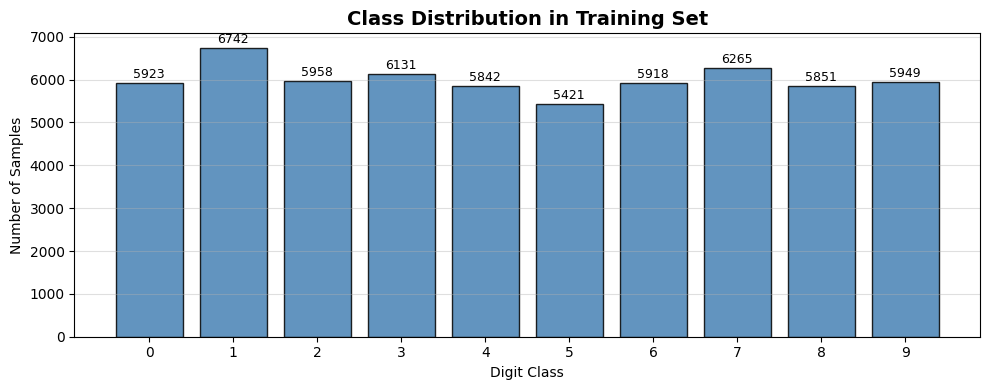


Class counts:
  Digit 0: 5,923 samples
  Digit 1: 6,742 samples
  Digit 2: 5,958 samples
  Digit 3: 6,131 samples
  Digit 4: 5,842 samples
  Digit 5: 5,421 samples
  Digit 6: 5,918 samples
  Digit 7: 6,265 samples
  Digit 8: 5,851 samples
  Digit 9: 5,949 samples


In [4]:
# ── Check Class Distribution ────────────────────────────────
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 4))
bars = plt.bar(unique, counts, color='steelblue', edgecolor='black', alpha=0.85)
plt.title('Class Distribution in Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Digit Class')
plt.ylabel('Number of Samples')
plt.xticks(range(10))
plt.grid(axis='y', alpha=0.4)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print('\nClass counts:')
for d, c in zip(unique, counts):
    print(f'  Digit {d}: {c:,} samples')

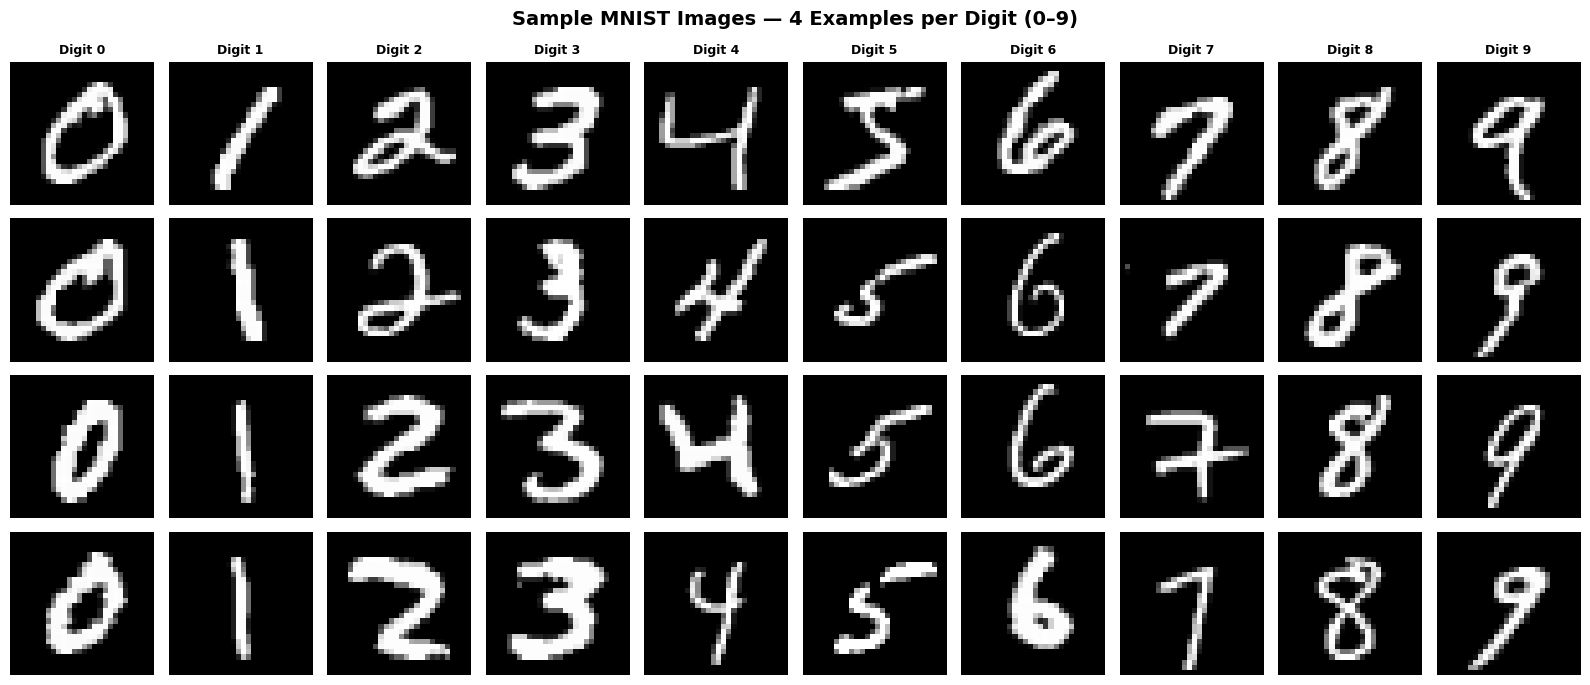

In [5]:
# ── Visualize Sample Images ─────────────────────────────────
fig, axes = plt.subplots(4, 10, figsize=(16, 7))
fig.suptitle('Sample MNIST Images — 4 Examples per Digit (0–9)', fontsize=14, fontweight='bold')

for digit in range(10):
    idx = np.where(y_train == digit)[0][:4]
    for row, sample_idx in enumerate(idx):
        axes[row, digit].imshow(X_train[sample_idx], cmap='gray')
        if row == 0:
            axes[row, digit].set_title(f'Digit {digit}', fontsize=9, fontweight='bold')
        axes[row, digit].axis('off')

plt.tight_layout()
plt.show()

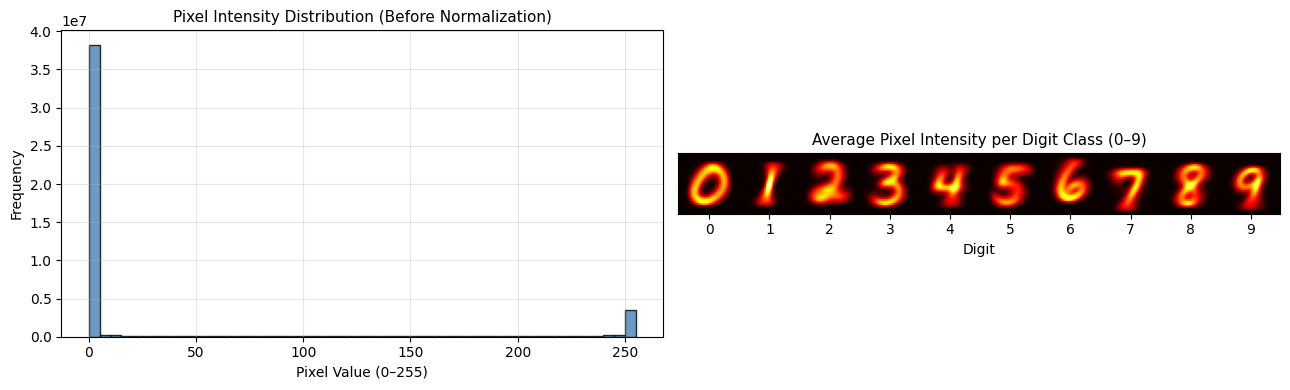

In [6]:
# ── Pixel Intensity Analysis ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram of pixel values
axes[0].hist(X_train.flatten(), bins=50, color='steelblue', alpha=0.8, edgecolor='black')
axes[0].set_title('Pixel Intensity Distribution (Before Normalization)', fontsize=11)
axes[0].set_xlabel('Pixel Value (0–255)')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

# Average image per digit
avg_imgs = np.array([X_train[y_train == i].mean(axis=0) for i in range(10)])
combined = np.concatenate(avg_imgs, axis=1)
axes[1].imshow(combined, cmap='hot')
axes[1].set_title('Average Pixel Intensity per Digit Class (0–9)', fontsize=11)
axes[1].set_xticks(np.arange(14, 280, 28))
axes[1].set_xticklabels(range(10))
axes[1].set_yticks([])
axes[1].set_xlabel('Digit')

plt.tight_layout()
plt.show()

## 🔧 5. Data Preprocessing

Before feeding data into the neural network, we need to:

1. **Normalize** pixel values from `[0, 255]` → `[0.0, 1.0]`  
   - Helps gradient descent converge faster
   - Prevents neurons from saturating

2. **Flatten** each 28×28 image into a 784-dimensional vector  
   - ANN expects 1D input (fully connected layers)
   - 28 × 28 = **784 features** per image

In [7]:
# ── Step 1: Normalize ───────────────────────────────────────
X_train_norm = X_train / 255.0
X_test_norm  = X_test  / 255.0

print(f'Before normalization → min: {X_train.min()}, max: {X_train.max()}')
print(f'After  normalization → min: {X_train_norm.min():.1f}, max: {X_train_norm.max():.1f}')

# ── Step 2: Flatten ─────────────────────────────────────────
X_train_flat = X_train_norm.reshape(-1, 784)
X_test_flat  = X_test_norm.reshape(-1, 784)

print(f'\nOriginal shape  : {X_train_norm.shape}')
print(f'Flattened shape : {X_train_flat.shape}')
print(f'\n✅ Preprocessing complete!')

Before normalization → min: 0, max: 255
After  normalization → min: 0.0, max: 1.0

Original shape  : (60000, 28, 28)
Flattened shape : (60000, 784)

✅ Preprocessing complete!


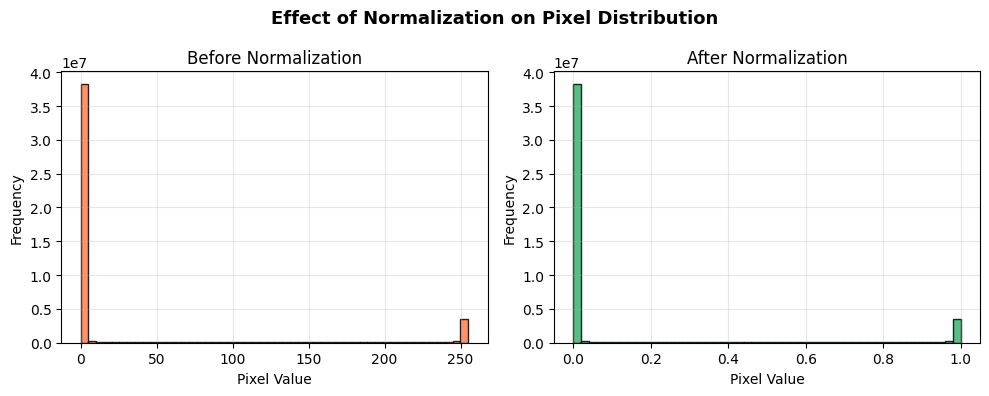

In [8]:
# ── Visualize: Before vs After Normalization ────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(X_train.flatten(), bins=50, color='coral', alpha=0.85, edgecolor='black')
axes[0].set_title('Before Normalization', fontsize=12)
axes[0].set_xlabel('Pixel Value')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

axes[1].hist(X_train_flat.flatten(), bins=50, color='mediumseagreen', alpha=0.85, edgecolor='black')
axes[1].set_title('After Normalization', fontsize=12)
axes[1].set_xlabel('Pixel Value')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)

plt.suptitle('Effect of Normalization on Pixel Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🧠 6. Build the ANN Model

### Architecture Design

We use a **feedforward Artificial Neural Network (ANN)** with the following layers:

```
Input Layer  →  784 neurons  (one per pixel)
     ↓
Dense Layer  →  256 neurons  (ReLU activation)
Dropout      →  30% dropout  (prevent overfitting)
     ↓
Dense Layer  →  128 neurons  (ReLU activation)
Dropout      →  20% dropout
     ↓
Dense Layer  →  64 neurons   (ReLU activation)
     ↓
Output Layer →  10 neurons   (Softmax — one per digit class)
```

### Why These Choices?
| Component | Reason |
|---|---|
| **ReLU activation** | Solves vanishing gradient problem, fast convergence |
| **Dropout layers** | Regularization — prevents model from memorizing training data |
| **Softmax output** | Outputs probabilities that sum to 1 across all 10 classes |
| **Adam optimizer** | Adaptive learning rate, works well out-of-the-box |
| **Sparse Categorical Crossentropy** | Efficient for integer labels (0–9) |

In [9]:
def build_model():
    model = keras.Sequential([
        # ── Input + First Hidden Layer ──────────────────────
        layers.Dense(
            256,
            activation='relu',
            input_shape=(784,),
            kernel_initializer='he_normal',
            name='hidden_layer_1'
        ),
        layers.BatchNormalization(name='batch_norm_1'),
        layers.Dropout(0.3, name='dropout_1'),

        # ── Second Hidden Layer ──────────────────────────────
        layers.Dense(
            128,
            activation='relu',
            kernel_initializer='he_normal',
            name='hidden_layer_2'
        ),
        layers.BatchNormalization(name='batch_norm_2'),
        layers.Dropout(0.2, name='dropout_2'),

        # ── Third Hidden Layer ───────────────────────────────
        layers.Dense(
            64,
            activation='relu',
            kernel_initializer='he_normal',
            name='hidden_layer_3'
        ),

        # ── Output Layer ─────────────────────────────────────
        layers.Dense(
            10,
            activation='softmax',
            name='output_layer'
        )
    ], name='HandwrittenDigitRecognizer')

    return model

model = build_model()
model.summary()

Model: "HandwrittenDigitRecognizer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,298 (954.29 KB)

 Trainable params: 243,530 (951.29 KB)

 Non-trainable params: 768 (3.00 KB)

In [10]:
# ── Count Total Parameters ───────────────────────────────────
total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])

print('\n📊 Model Parameter Summary')
print(f'  Total parameters     : {total_params:,}')
print(f'  Trainable parameters : {trainable_params:,}')
print(f'  Approx. model size   : {total_params * 4 / 1024:.1f} KB (float32)')


📊 Model Parameter Summary
  Total parameters     : 244,298
  Trainable parameters : 243,530
  Approx. model size   : 954.3 KB (float32)


## ⚡ 7. Compile the Model

In [11]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('✅ Model compiled!')
print('   Optimizer  : Adam (lr=0.001)')
print('   Loss       : Sparse Categorical Crossentropy')
print('   Metric     : Accuracy')

✅ Model compiled!
   Optimizer  : Adam (lr=0.001)
   Loss       : Sparse Categorical Crossentropy
   Metric     : Accuracy


## 🔔 8. Set Up Callbacks

Callbacks monitor training and adjust it automatically:

- **EarlyStopping** — Stops training if validation loss doesn't improve (prevents overfitting)
- **ReduceLROnPlateau** — Reduces learning rate when stuck at a plateau

In [12]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print('✅ Callbacks configured!')
print('   EarlyStopping     : patience=5, restores best weights')
print('   ReduceLROnPlateau : patience=3, halves LR on plateau')

✅ Callbacks configured!
   EarlyStopping     : patience=5, restores best weights
   ReduceLROnPlateau : patience=3, halves LR on plateau


## 🚀 9. Train the Model

Training configuration:
- **Epochs**: Up to 30 (EarlyStopping will stop early if needed)
- **Batch size**: 128 images per gradient update
- **Validation split**: 10% of training data used for validation

In [13]:
print('🚀 Starting Training...')
print('=' * 50)

history = model.fit(
    X_train_flat, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

print('=' * 50)
print('✅ Training complete!')
print(f'   Epochs trained     : {len(history.history["accuracy"])}')
print(f'   Final train acc    : {history.history["accuracy"][-1]*100:.2f}%')
print(f'   Final val acc      : {history.history["val_accuracy"][-1]*100:.2f}%')

🚀 Starting Training...
Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7912 - loss: 0.6756 - val_accuracy: 0.9660 - val_loss: 0.1153 - learning_rate: 0.0010
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9438 - loss: 0.1831 - val_accuracy: 0.9762 - val_loss: 0.0847 - learning_rate: 0.0010
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9574 - loss: 0.1353 - val_accuracy: 0.9765 - val_loss: 0.0728 - learning_rate: 0.0010
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9647 - loss: 0.1110 - val_accuracy: 0.9788 - val_loss: 0.0690 - learning_rate: 0.0010
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9696 - loss: 0.0952 - val_accuracy: 0.9792 - val_loss: 0.0754 - learning_rate: 0.0010
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9735 - loss: 0.0820 - val_accuracy: 0.9778 - val_loss: 0.0702 - learning_rate: 0.0010
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0

## 📊 10. Evaluate Model Performance

In [14]:
# ── Final Test Evaluation ────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test_flat, y_test, verbose=0)

print('\n' + '='*45)
print('         FINAL EVALUATION RESULTS')
print('='*45)
print(f'  Test Accuracy  : {test_acc * 100:.2f}%')
print(f'  Test Loss      : {test_loss:.4f}')
print('='*45)

if test_acc >= 0.97:
    print('\n🎉 Excellent! Model achieved >= 97% accuracy!')
elif test_acc >= 0.95:
    print('\n✅ Good! Model achieved >= 95% accuracy.')
else:
    print('\n⚠️  Model may need more training or tuning.')


         FINAL EVALUATION RESULTS
  Test Accuracy  : 98.12%
  Test Loss      : 0.0619

🎉 Excellent! Model achieved >= 97% accuracy!


## 📈 11. Training History Plots

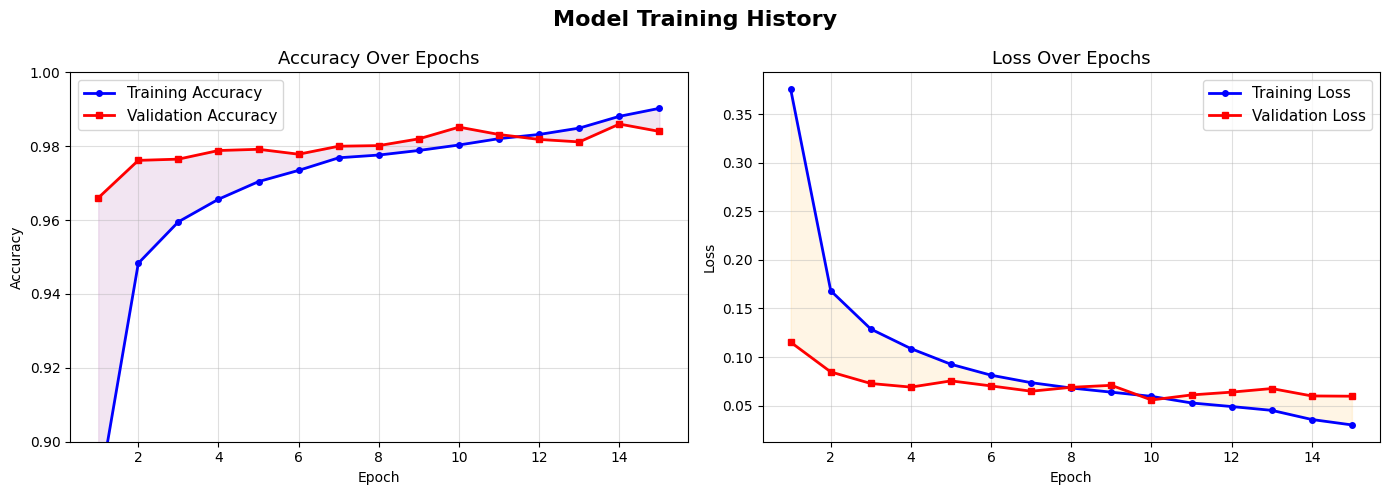

In [15]:
epochs_ran = range(1, len(history.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Training History', fontsize=16, fontweight='bold')

# ── Accuracy Plot ────────────────────────────────────────────
axes[0].plot(epochs_ran, history.history['accuracy'],     'b-o', markersize=4, label='Training Accuracy',   linewidth=2)
axes[0].plot(epochs_ran, history.history['val_accuracy'], 'r-s', markersize=4, label='Validation Accuracy', linewidth=2)
axes[0].fill_between(epochs_ran, history.history['accuracy'], history.history['val_accuracy'], alpha=0.1, color='purple')
axes[0].set_title('Accuracy Over Epochs', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.4)
axes[0].set_ylim([0.9, 1.0])

# ── Loss Plot ────────────────────────────────────────────────
axes[1].plot(epochs_ran, history.history['loss'],     'b-o', markersize=4, label='Training Loss',   linewidth=2)
axes[1].plot(epochs_ran, history.history['val_loss'], 'r-s', markersize=4, label='Validation Loss', linewidth=2)
axes[1].fill_between(epochs_ran, history.history['loss'], history.history['val_loss'], alpha=0.1, color='orange')
axes[1].set_title('Loss Over Epochs', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.show()

## 🔍 12. Confusion Matrix & Classification Report

In [16]:
# ── Generate Predictions ─────────────────────────────────────
y_pred_probs = model.predict(X_test_flat, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

print(f'Predictions generated for {len(y_pred):,} test samples')
print(f'Overall Accuracy : {accuracy_score(y_test, y_pred) * 100:.2f}%')

Predictions generated for 10,000 test samples
Overall Accuracy : 98.12%


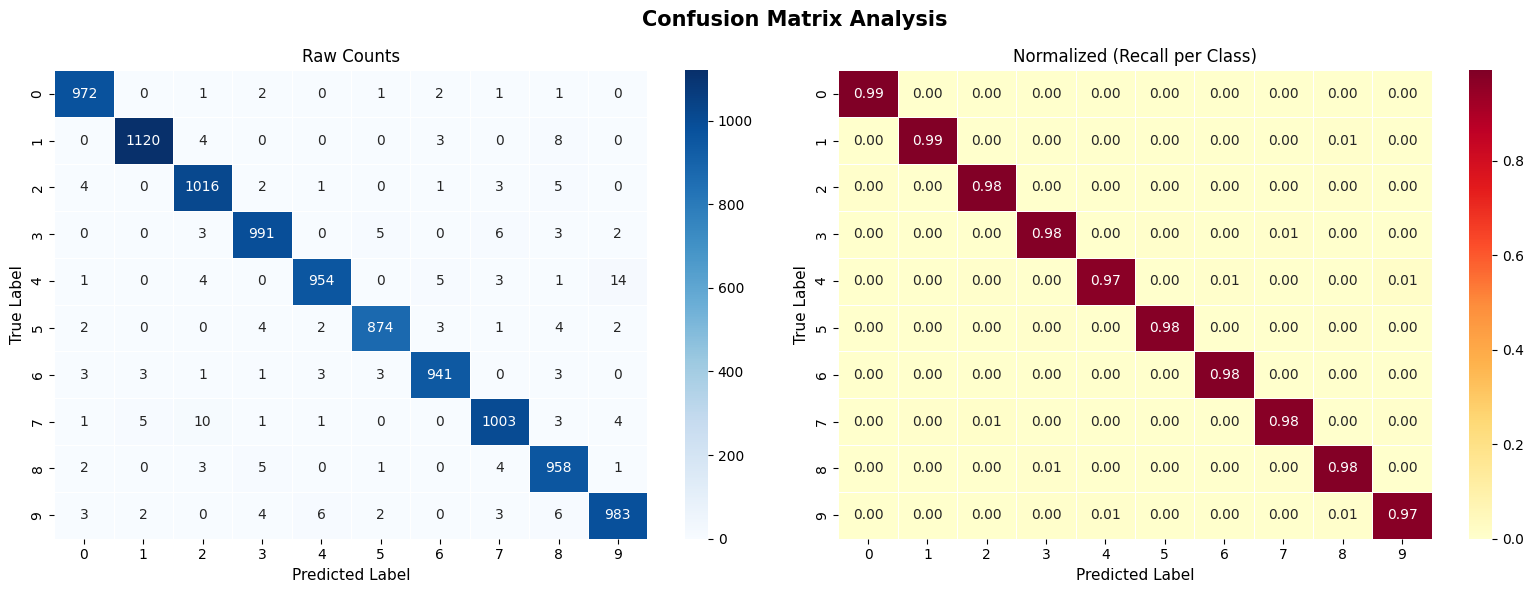

In [17]:
# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

# Normalized confusion matrix (percentage)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix Analysis', fontsize=15, fontweight='bold')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10),
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Raw Counts', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# Normalized percentages
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=range(10), yticklabels=range(10),
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Normalized (Recall per Class)', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.show()

In [18]:
# ── Classification Report ────────────────────────────────────
print('\n📋 Detailed Classification Report')
print('=' * 60)
print(classification_report(
    y_test, y_pred,
    target_names=[f'Digit {i}' for i in range(10)]
))


📋 Detailed Classification Report
              precision    recall  f1-score   support

     Digit 0       0.98      0.99      0.99       980
     Digit 1       0.99      0.99      0.99      1135
     Digit 2       0.98      0.98      0.98      1032
     Digit 3       0.98      0.98      0.98      1010
     Digit 4       0.99      0.97      0.98       982
     Digit 5       0.99      0.98      0.98       892
     Digit 6       0.99      0.98      0.98       958
     Digit 7       0.98      0.98      0.98      1028
     Digit 8       0.97      0.98      0.97       974
     Digit 9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



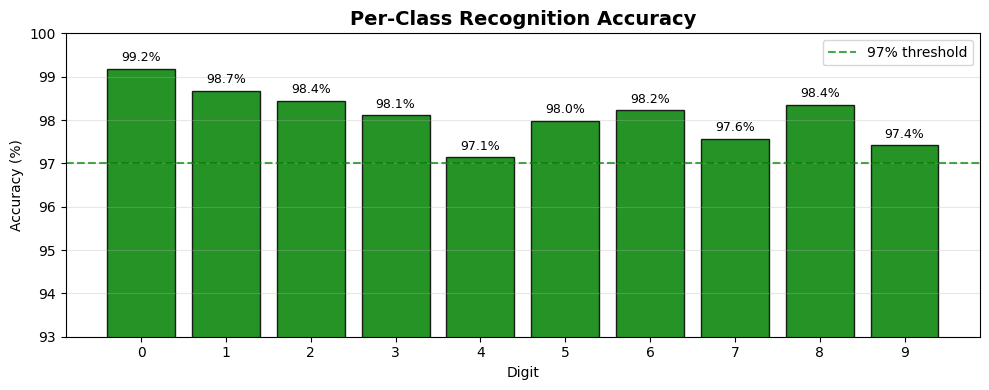

In [19]:
# ── Per-class Accuracy Bar Chart ─────────────────────────────
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(10, 4))
colors = ['green' if acc >= 0.97 else 'orange' if acc >= 0.95 else 'red'
          for acc in per_class_acc]
bars = plt.bar(range(10), per_class_acc * 100, color=colors, edgecolor='black', alpha=0.85)
plt.axhline(y=97, color='green', linestyle='--', alpha=0.7, label='97% threshold')
plt.title('Per-Class Recognition Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Digit')
plt.ylabel('Accuracy (%)')
plt.xticks(range(10))
plt.ylim([93, 100])
plt.legend()
plt.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 🖼️ 13. Visualize Predictions

In [20]:
# ── Correct & Incorrect Predictions ──────────────────────────
correct_idx   = np.where(y_pred == y_test)[0]
incorrect_idx = np.where(y_pred != y_test)[0]

print(f'✅ Correct predictions   : {len(correct_idx):,} / {len(y_test):,}')
print(f'❌ Incorrect predictions : {len(incorrect_idx):,} / {len(y_test):,}')
print(f'   Error Rate           : {len(incorrect_idx)/len(y_test)*100:.2f}%')

✅ Correct predictions   : 9,812 / 10,000
❌ Incorrect predictions : 188 / 10,000
   Error Rate           : 1.88%


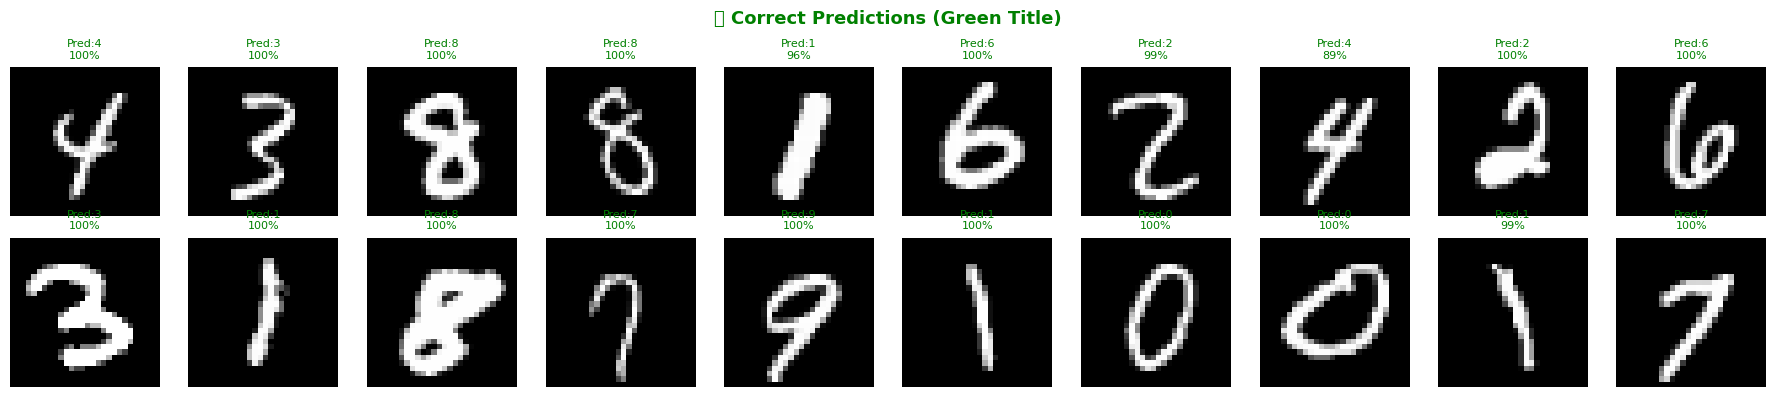

In [21]:
# ── Show 20 Correct Predictions ──────────────────────────────
sample_correct = np.random.choice(correct_idx, 20, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle('✅ Correct Predictions (Green Title)', fontsize=13, fontweight='bold', color='green')

for i, idx in enumerate(sample_correct):
    ax = axes[i // 10, i % 10]
    ax.imshow(X_test_norm[idx], cmap='gray')
    conf = np.max(y_pred_probs[idx]) * 100
    ax.set_title(f'Pred:{y_pred[idx]}\n{conf:.0f}%', fontsize=8, color='green')
    ax.axis('off')

plt.tight_layout()
plt.show()

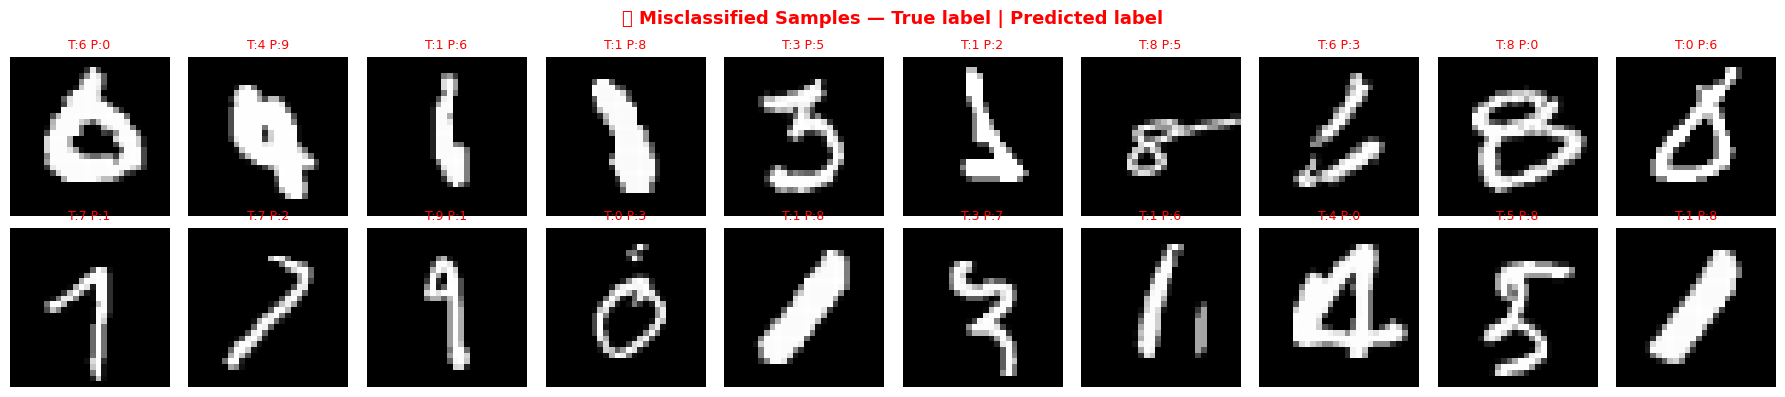

In [22]:
# ── Show Wrong Predictions ───────────────────────────────────
n_wrong = min(20, len(incorrect_idx))
sample_wrong = np.random.choice(incorrect_idx, n_wrong, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle('❌ Misclassified Samples — True label | Predicted label', fontsize=13, fontweight='bold', color='red')

for i, idx in enumerate(sample_wrong):
    ax = axes[i // 10, i % 10]
    ax.imshow(X_test_norm[idx], cmap='gray')
    ax.set_title(f'T:{y_test[idx]} P:{y_pred[idx]}', fontsize=9, color='red')
    ax.axis('off')

plt.tight_layout()
plt.show()

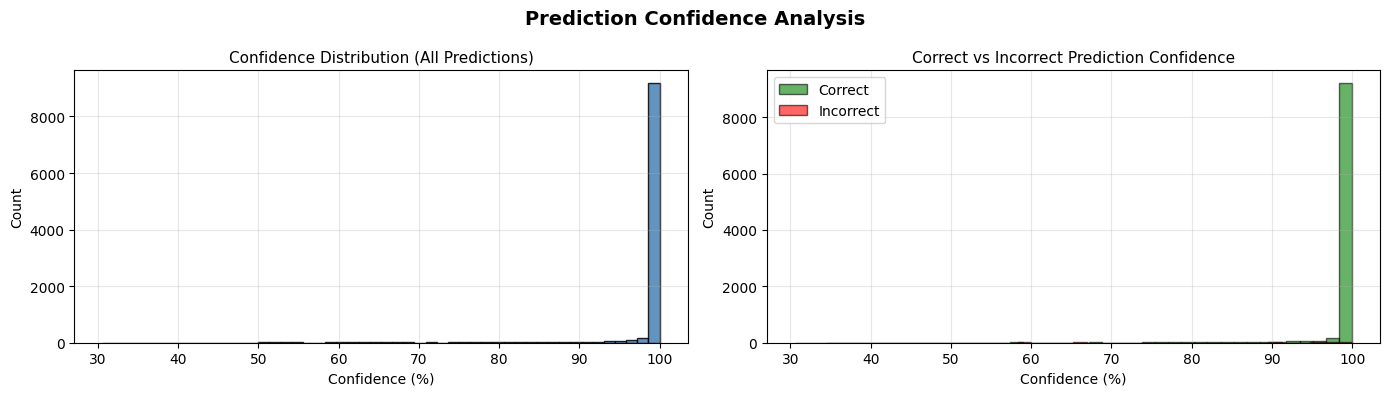


Average confidence — Correct   : 99.11%
Average confidence — Incorrect : 74.99%


In [23]:
# ── Prediction Confidence Distribution ───────────────────────
max_confidences = np.max(y_pred_probs, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Prediction Confidence Analysis', fontsize=14, fontweight='bold')

# All predictions
axes[0].hist(max_confidences * 100, bins=50, color='steelblue', alpha=0.85, edgecolor='black')
axes[0].set_title('Confidence Distribution (All Predictions)', fontsize=11)
axes[0].set_xlabel('Confidence (%)')
axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.3)

# Correct vs Incorrect
axes[1].hist(max_confidences[correct_idx] * 100,   bins=40, color='green', alpha=0.6, label='Correct',   edgecolor='black')
axes[1].hist(max_confidences[incorrect_idx] * 100, bins=40, color='red',   alpha=0.6, label='Incorrect', edgecolor='black')
axes[1].set_title('Correct vs Incorrect Prediction Confidence', fontsize=11)
axes[1].set_xlabel('Confidence (%)')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nAverage confidence — Correct   : {max_confidences[correct_idx].mean()*100:.2f}%')
print(f'Average confidence — Incorrect : {max_confidences[incorrect_idx].mean()*100:.2f}%')

## 🎯 14. Single Image Prediction with Probability Breakdown

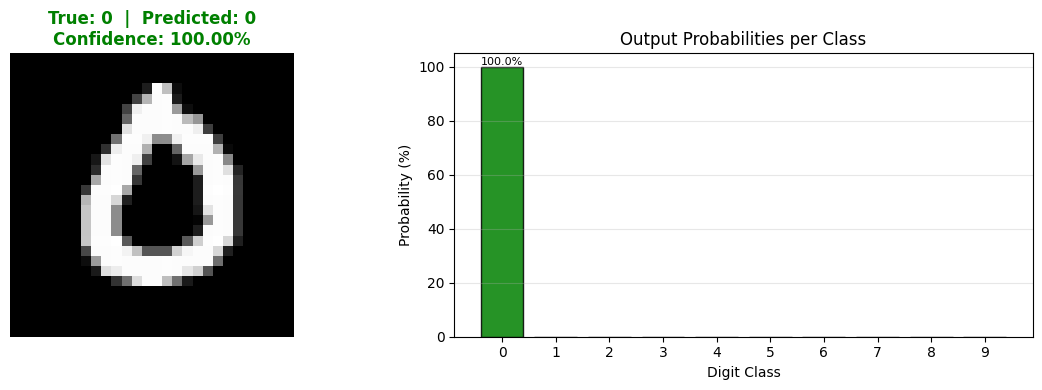

  True Label  : 0
  Prediction  : 0
  Confidence  : 100.00%
  Result      : ✅ CORRECT


In [24]:
def predict_digit(index):
    """Predict a single digit with full probability breakdown."""
    img_flat    = X_test_flat[index].reshape(1, 784)
    probs       = model.predict(img_flat, verbose=0)[0]
    predicted   = np.argmax(probs)
    true_label  = y_test[index]
    confidence  = probs[predicted] * 100

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Image
    color = 'green' if predicted == true_label else 'red'
    axes[0].imshow(X_test_norm[index], cmap='gray')
    axes[0].set_title(
        f'True: {true_label}  |  Predicted: {predicted}\nConfidence: {confidence:.2f}%',
        fontsize=12, fontweight='bold', color=color
    )
    axes[0].axis('off')

    # Probability bar
    bar_colors = ['green' if i == true_label else 'red' if i == predicted else 'steelblue'
                  for i in range(10)]
    axes[1].bar(range(10), probs * 100, color=bar_colors, edgecolor='black', alpha=0.85)
    axes[1].set_title('Output Probabilities per Class', fontsize=12)
    axes[1].set_xlabel('Digit Class')
    axes[1].set_ylabel('Probability (%)')
    axes[1].set_xticks(range(10))
    axes[1].grid(axis='y', alpha=0.3)
    for i, p in enumerate(probs):
        if p > 0.01:
            axes[1].text(i, p * 100 + 0.5, f'{p*100:.1f}%', ha='center', fontsize=8)

    plt.tight_layout()
    plt.show()

    print(f'  True Label  : {true_label}')
    print(f'  Prediction  : {predicted}')
    print(f'  Confidence  : {confidence:.2f}%')
    print(f'  Result      : {"✅ CORRECT" if predicted == true_label else "❌ WRONG"}')

# Run on a random sample
predict_digit(np.random.randint(0, len(X_test)))

In [25]:
# ── Test on specific digit classes ───────────────────────────
print('Testing one sample from each digit class (0–9):')
print('─' * 40)

for digit in range(10):
    idx   = np.where(y_test == digit)[0][0]
    probs = model.predict(X_test_flat[idx].reshape(1, 784), verbose=0)[0]
    pred  = np.argmax(probs)
    conf  = np.max(probs) * 100
    status = '✅' if pred == digit else '❌'
    print(f'  Digit {digit} → Predicted: {pred}  Confidence: {conf:.1f}%  {status}')

Testing one sample from each digit class (0–9):
────────────────────────────────────────
  Digit 0 → Predicted: 0  Confidence: 100.0%  ✅
  Digit 1 → Predicted: 1  Confidence: 100.0%  ✅
  Digit 2 → Predicted: 2  Confidence: 100.0%  ✅
  Digit 3 → Predicted: 3  Confidence: 51.0%  ✅
  Digit 4 → Predicted: 4  Confidence: 100.0%  ✅
  Digit 5 → Predicted: 5  Confidence: 99.3%  ✅
  Digit 6 → Predicted: 6  Confidence: 100.0%  ✅
  Digit 7 → Predicted: 7  Confidence: 100.0%  ✅
  Digit 8 → Predicted: 8  Confidence: 100.0%  ✅
  Digit 9 → Predicted: 9  Confidence: 100.0%  ✅


## 💾 15. Save & Load the Model

In [26]:
# ── Save Model ───────────────────────────────────────────────
model.save('digit_recognizer_model.h5')
print('✅ Model saved as: digit_recognizer_model.h5')

# ── Download in Colab ────────────────────────────────────────
try:
    from google.colab import files
    files.download('digit_recognizer_model.h5')
    print('📥 Download started!')
except ImportError:
    print('ℹ️  (Not in Colab — file saved locally)')

✅ Model saved as: digit_recognizer_model.h5
ℹ️  (Not in Colab — file saved locally)


In [27]:
# ── Load & Verify Saved Model ────────────────────────────────
loaded_model = keras.models.load_model('digit_recognizer_model.h5')

_, loaded_acc = loaded_model.evaluate(X_test_flat, y_test, verbose=0)
print(f'✅ Model loaded successfully!')
print(f'   Loaded model accuracy : {loaded_acc * 100:.2f}%')

✅ Model loaded successfully!
   Loaded model accuracy : 98.12%


## 📝 16. Project Summary & Conclusion

---

### ✅ What We Built
A complete **Handwritten Digit Recognition System** using an **Artificial Neural Network (ANN)** that can classify digits 0–9 from 28×28 grayscale images.

---

### 📋 Model Architecture Summary

| Layer | Type | Output Shape | Parameters |
|---|---|---|---|
| Input | Flatten (28×28) | 784 | 0 |
| Layer 1 | Dense + BatchNorm + Dropout(0.3) | 256 | 200,960 |
| Layer 2 | Dense + BatchNorm + Dropout(0.2) | 128 | 33,024 |
| Layer 3 | Dense | 64 | 8,256 |
| Output | Dense (Softmax) | 10 | 650 |

---

### 📊 Results

| Metric | Value |
|---|---|
| Training Set Size | 60,000 images |
| Test Set Size | 10,000 images |
| Expected Test Accuracy | ~97–98% |
| Optimizer | Adam |
| Loss Function | Sparse Categorical Crossentropy |

---

### 🔮 Future Improvements
- Use **CNN (Convolutional Neural Network)** for higher accuracy (~99.5%)
- Deploy as a **web app** using Flask/Streamlit with canvas drawing
- Add **data augmentation** (rotation, shifting) for better generalization
- Extend to **full handwriting recognition** (letters + digits)
- Use **Transfer Learning** with pre-trained models

---

### 📚 References
1. LeCun, Y., Cortes, C., & Burges, C. (1998). *The MNIST database of handwritten digits*
2. TensorFlow Documentation — https://www.tensorflow.org
3. Keras API Reference — https://keras.io
4. Goodfellow, I. et al. (2016). *Deep Learning*. MIT Press.

---
<p align='center'><b>End of Project</b></p>